Here, I'll include my problem statement and approach later.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [25]:

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [32]:
import streamlit as st
import joblib

In [5]:
df_master = pd.read_csv('gs_master_dataset.csv')
df_yahoo = pd.read_csv('gs_yahoo_finance.csv')
df_nasdaq = pd.read_csv('gs_nasdaq.csv')
df_investing = pd.read_csv('gs_investing_com.csv')
df_barchart = pd.read_csv('gs_barchart.csv')
df_marketwatch = pd.read_csv('gs_marketwatch.csv')

In [9]:
df_master.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Source
0,1999-05-04 00:00:00-04:00,52.313516,53.173936,48.183502,48.441628,22320900,0.0,0.0,Barchart (via proxy)
1,1999-05-05 00:00:00-04:00,48.097432,48.097432,45.602216,47.581181,7565700,0.0,0.0,Barchart (via proxy)
2,1999-05-06 00:00:00-04:00,46.806815,47.753276,46.161500,46.763794,2905700,0.0,0.0,Barchart (via proxy)
3,1999-05-07 00:00:00-04:00,46.763814,51.539144,45.946415,51.022892,4862300,0.0,0.0,Barchart (via proxy)
4,1999-05-10 00:00:00-04:00,50.506625,50.592667,48.355576,48.656723,2589400,0.0,0.0,Barchart (via proxy)


In [7]:

df_master['Date'] = pd.to_datetime(df_master['Date'])
df_master = df_master.sort_values('Date').reset_index(drop=True)

In [10]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6755 entries, 0 to 6754
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          6755 non-null   object 
 1   Open          6755 non-null   float64
 2   High          6755 non-null   float64
 3   Low           6755 non-null   float64
 4   Close         6755 non-null   float64
 5   Volume        6755 non-null   int64  
 6   Dividends     6755 non-null   float64
 7   Stock Splits  6755 non-null   float64
 8   Source        6755 non-null   object 
dtypes: float64(6), int64(1), object(2)
memory usage: 475.1+ KB


In [12]:
source_counts = df_master['Source'].value_counts()
date_range = f"{df_master['Date'].min().date()} to {df_master['Date'].max().date()}"

source_counts

Source
Barchart (via proxy)    6755
Name: count, dtype: int64

In [13]:
date_range

'1999-05-04 to 2026-03-11'

Feature Engineering Begins Here

In [ ]:
def create_technical_indicators(df):
    df['Date'] = pd.to_datetime(df['Date'])

    # Creating indicators
    df = df.copy()
    
    # To show if stock is trending up/down using moving averages for different periods ((short-term) 1 week, (medium-term) 1 month, (long-term) 2.5 months)
    df['SMA_5'] = df['Close'].rolling(window=5).mean() 
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['SMA_50'] = df['Close'].rolling(window=50).mean()
    
    # Which trend is rising faster?
    df['SMA_5_20_Ratio'] = df['SMA_5'] / df['SMA_20']
    
    # To see how fast prices change over different periods (1 day, 1 week, 1 month)    
    df['Returns_1d'] = df['Close'].pct_change(1)
    df['Returns_5d'] = df['Close'].pct_change(5)
    df['Returns_20d'] = df['Close'].pct_change(20)
    
    # Calculating RSI (https://www.investopedia.com/terms/r/rsi.asp): >70 = overbought (might drop), <30 = oversold (might rise)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # Measuring Volatility - How much does the price move?
    df['Volatility_5d'] = df['Returns_1d'].rolling(window=5).std()
    df['Volatility_20d'] = df['Returns_1d'].rolling(window=20).std()
    
    df['High_Low_Range'] = (df['High'] - df['Low']) / df['Close']
    
    
    # How many shares traded? - avg volume // volume vs avg
    df['Volume_SMA_20'] = df['Volume'].rolling(window=20).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_SMA_20']
    
    # Price patterns - Previous closing prices, previous returns, previous volume
    df['Close_Lag_1'] = df['Close'].shift(1)
    df['Close_Lag_5'] = df['Close'].shift(5)
    df['Close_Lag_20'] = df['Close'].shift(20)
    
    df['Returns_Lag_1'] = df['Returns_1d'].shift(1)
    df['Returns_Lag_5'] = df['Returns_1d'].shift(5)
    
    df['Volume_Lag_1'] = df['Volume'].shift(1)
    
    # Do the stocks behave differently on different days/months?        
    df['Day_of_Week'] = df['Date'].dt.dayofweek
    df['Month'] = df['Date'].dt.month      
    df['Quarter'] = df['Date'].dt.quarter
    
    return df

# having so many issues with date.
df_master['Date'] = pd.to_datetime(df_master['Date'], format='%Y-%m-%d %H:%M:%S%z', utc=True)
df_master['Date'] = df_master['Date'].dt.date
df_master['Date'] = pd.to_datetime(df_master['Date'])

df_features = create_technical_indicators(df_master)

# Some rows had NaN values because of the rolling windows, so I'll drop them
df_features = df_features.dropna()

feature_cols = [col for col in df_features.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'Source']]

print(f"Total features created: {len(feature_cols)}")
df_features.shape

Total features created: 22


(6706, 31)

In [20]:
feature_cols

['SMA_5',
 'SMA_20',
 'SMA_50',
 'SMA_5_20_Ratio',
 'Returns_1d',
 'Returns_5d',
 'Returns_20d',
 'RSI',
 'Volatility_5d',
 'Volatility_20d',
 'High_Low_Range',
 'Volume_SMA_20',
 'Volume_Ratio',
 'Close_Lag_1',
 'Close_Lag_5',
 'Close_Lag_20',
 'Returns_Lag_1',
 'Returns_Lag_5',
 'Volume_Lag_1',
 'Day_of_Week',
 'Month',
 'Quarter']

In [19]:
df_master.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Source
0,1999-05-04,52.313516,53.173936,48.183502,48.441628,22320900,0.0,0.0,Barchart (via proxy)
1,1999-05-05,48.097432,48.097432,45.602216,47.581181,7565700,0.0,0.0,Barchart (via proxy)
2,1999-05-06,46.806815,47.753276,46.161500,46.763794,2905700,0.0,0.0,Barchart (via proxy)
3,1999-05-07,46.763814,51.539144,45.946415,51.022892,4862300,0.0,0.0,Barchart (via proxy)
4,1999-05-10,50.506625,50.592667,48.355576,48.656723,2589400,0.0,0.0,Barchart (via proxy)


Next, creating the target variable.

In [23]:
def create_targets(df, horizons=[1, 5, 20]):
    df = df.copy()    
    for horizon in horizons:
        # shifting the closing price backwards to get future price
        df[f'Target_{horizon}d'] = df['Close'].shift(-horizon)
    return df

df_features = create_targets(df_features, horizons=[1, 5, 20])
df_features = df_features.dropna()

print(f"Final dataset shape: {df_features.shape}")
df_features[['Date', 'Close', 'Target_1d', 'Target_5d', 'Target_20d']].tail(10)

Final dataset shape: (6646, 34)


,Date,Close,Target_1d,Target_5d,Target_20d
6685,2025-11-28,817.661926,802.635925,850.086182,887.509277
6686,2025-12-01,802.635925,810.942261,862.152710,879.789856
6687,2025-12-02,810.942261,832.190430,871.990967,874.398254
6688,2025-12-03,832.190430,833.443787,884.584656,909.553284
6689,2025-12-04,833.443787,850.086182,906.260620,943.474731
6690,2025-12-05,850.086182,862.152710,883.311401,950.467896
6691,2025-12-08,862.152710,871.990967,884.932861,936.093567
6692,2025-12-09,871.990967,884.584656,874.547485,929.935974
6693,2025-12-10,884.584656,906.260620,867.763184,934.064209
6694,2025-12-11,906.260620,883.311401,871.712402,944.578918


Data Split

In [24]:
# using everything before 2024 = training, everything after 2024 = testing
split_date = '2024-01-01'

train_df = df_features[df_features['Date'] < split_date].copy()
test_df = df_features[df_features['Date'] >= split_date].copy()

print(f"Training data: {train_df.shape[0]} rows ({train_df['Date'].min()} to {train_df['Date'].max()})")
print(f"Testing data: {test_df.shape[0]} rows ({test_df['Date'].min()} to {test_df['Date'].max()})")

# Feature columns are everything except Date, OHLCV, and targets
feature_cols = [col for col in df_features.columns if col not in ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 
                                                                  'Stock Splits', 'Source', 'Target_1d', 'Target_5d', 'Target_20d']]

print(f"\nFeatures in use: {len(feature_cols)}")
print(feature_cols)

Training data: 6157 rows (1999-07-14 00:00:00 to 2023-12-29 00:00:00)
Testing data: 489 rows (2024-01-02 00:00:00 to 2025-12-11 00:00:00)

Features in use: 22
['SMA_5', 'SMA_20', 'SMA_50', 'SMA_5_20_Ratio', 'Returns_1d', 'Returns_5d', 'Returns_20d', 'RSI', 'Volatility_5d', 'Volatility_20d', 'High_Low_Range', 'Volume_SMA_20', 'Volume_Ratio', 'Close_Lag_1', 'Close_Lag_5', 'Close_Lag_20', 'Returns_Lag_1', 'Returns_Lag_5', 'Volume_Lag_1', 'Day_of_Week', 'Month', 'Quarter']


Training the model.

In [26]:
# Training 3 models for each horizon (1 day, 1 week, 1 month)
horizons = [1, 5, 20]
models = {}
scalers = {}
predictions = {}

for horizon in horizons:
    print(f"Training models for {horizon}-day prediction")

    X_train = train_df[feature_cols]
    y_train = train_df[f'Target_{horizon}d']
    X_test = test_df[feature_cols]
    y_test = test_df[f'Target_{horizon}d']
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    scalers[f'{horizon}d'] = scaler
    
    # Linear Regression Model
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    lr_pred = lr.predict(X_test_scaled)
    
    # Random Forest Model
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    
    # XGBoost Model
    xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    
    # An Ensemble of All 3 Models (Average)
    ensemble_pred = (lr_pred + rf_pred + xgb_pred) / 3
    
    # Store models and predictions
    models[f'{horizon}d'] = {
        'Linear Regression': lr,
        'Random Forest': rf,
        'XGBoost': xgb_model
    }
    
    predictions[f'{horizon}d'] = {
        'actual': y_test.values,
        'Linear Regression': lr_pred,
        'Random Forest': rf_pred,
        'XGBoost': xgb_pred,
        'Ensemble': ensemble_pred
    }
    
    print(f"Trained 3 models for {horizon}-day horizon")

print("\n All models trained successfully")

Training models for 1-day prediction
Trained 3 models for 1-day horizon
Training models for 5-day prediction
Trained 3 models for 5-day horizon
Training models for 20-day prediction
Trained 3 models for 20-day horizon

 All models trained successfully


Evaluating the model.

In [27]:
def calculate_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    actual_direction = np.sign(np.diff(actual))
    pred_direction = np.sign(np.diff(predicted))
    directional_accuracy = np.mean(actual_direction == pred_direction) * 100
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE': mape,
        'Directional Accuracy': directional_accuracy
    }

results = {}

for horizon in [1, 5, 20]:
    print(f"{horizon}-DAY PREDICTION RESULTS")
    results[f'{horizon}d'] = {}
    
    actual = predictions[f'{horizon}d']['actual']
    
    for model_name in ['Linear Regression', 'Random Forest', 'XGBoost', 'Ensemble']:
        pred = predictions[f'{horizon}d'][model_name]
        metrics = calculate_metrics(actual, pred)
        results[f'{horizon}d'][model_name] = metrics
        
        print(f"\n{model_name}:")
        print(f"  RMSE: ${metrics['RMSE']:.2f}")
        print(f"  MAE: ${metrics['MAE']:.2f}")
        print(f"  R²: {metrics['R²']:.4f}")
        print(f"  MAPE: {metrics['MAPE']:.2f}%")
        print(f"  Directional Accuracy: {metrics['Directional Accuracy']:.2f}%")

1-DAY PREDICTION RESULTS

Linear Regression:
  RMSE: $12.95
  MAE: $9.02
  R²: 0.9910
  MAPE: 1.60%
  Directional Accuracy: 50.20%

Random Forest:
  RMSE: $233.86
  MAE: $190.27
  R²: -1.9204
  MAPE: 30.19%
  Directional Accuracy: 48.57%

XGBoost:
  RMSE: $236.88
  MAE: $193.96
  R²: -1.9964
  MAPE: 30.88%
  Directional Accuracy: 48.16%

Ensemble:
  RMSE: $157.84
  MAE: $128.78
  R²: -0.3303
  MAPE: 20.47%
  Directional Accuracy: 48.36%
5-DAY PREDICTION RESULTS

Linear Regression:
  RMSE: $24.42
  MAE: $17.44
  R²: 0.9690
  MAPE: 3.05%
  Directional Accuracy: 52.05%

Random Forest:
  RMSE: $251.43
  MAE: $212.57
  R²: -2.2854
  MAPE: 34.27%
  Directional Accuracy: 53.28%

XGBoost:
  RMSE: $253.96
  MAE: $216.04
  R²: -2.3517
  MAPE: 34.97%
  Directional Accuracy: 50.82%

Ensemble:
  RMSE: $171.40
  MAE: $145.06
  R²: -0.5267
  MAPE: 23.42%
  Directional Accuracy: 49.59%
20-DAY PREDICTION RESULTS

Linear Regression:
  RMSE: $50.05
  MAE: $39.18
  R²: 0.8838
  MAPE: 6.54%
  Directional A

Visualisation

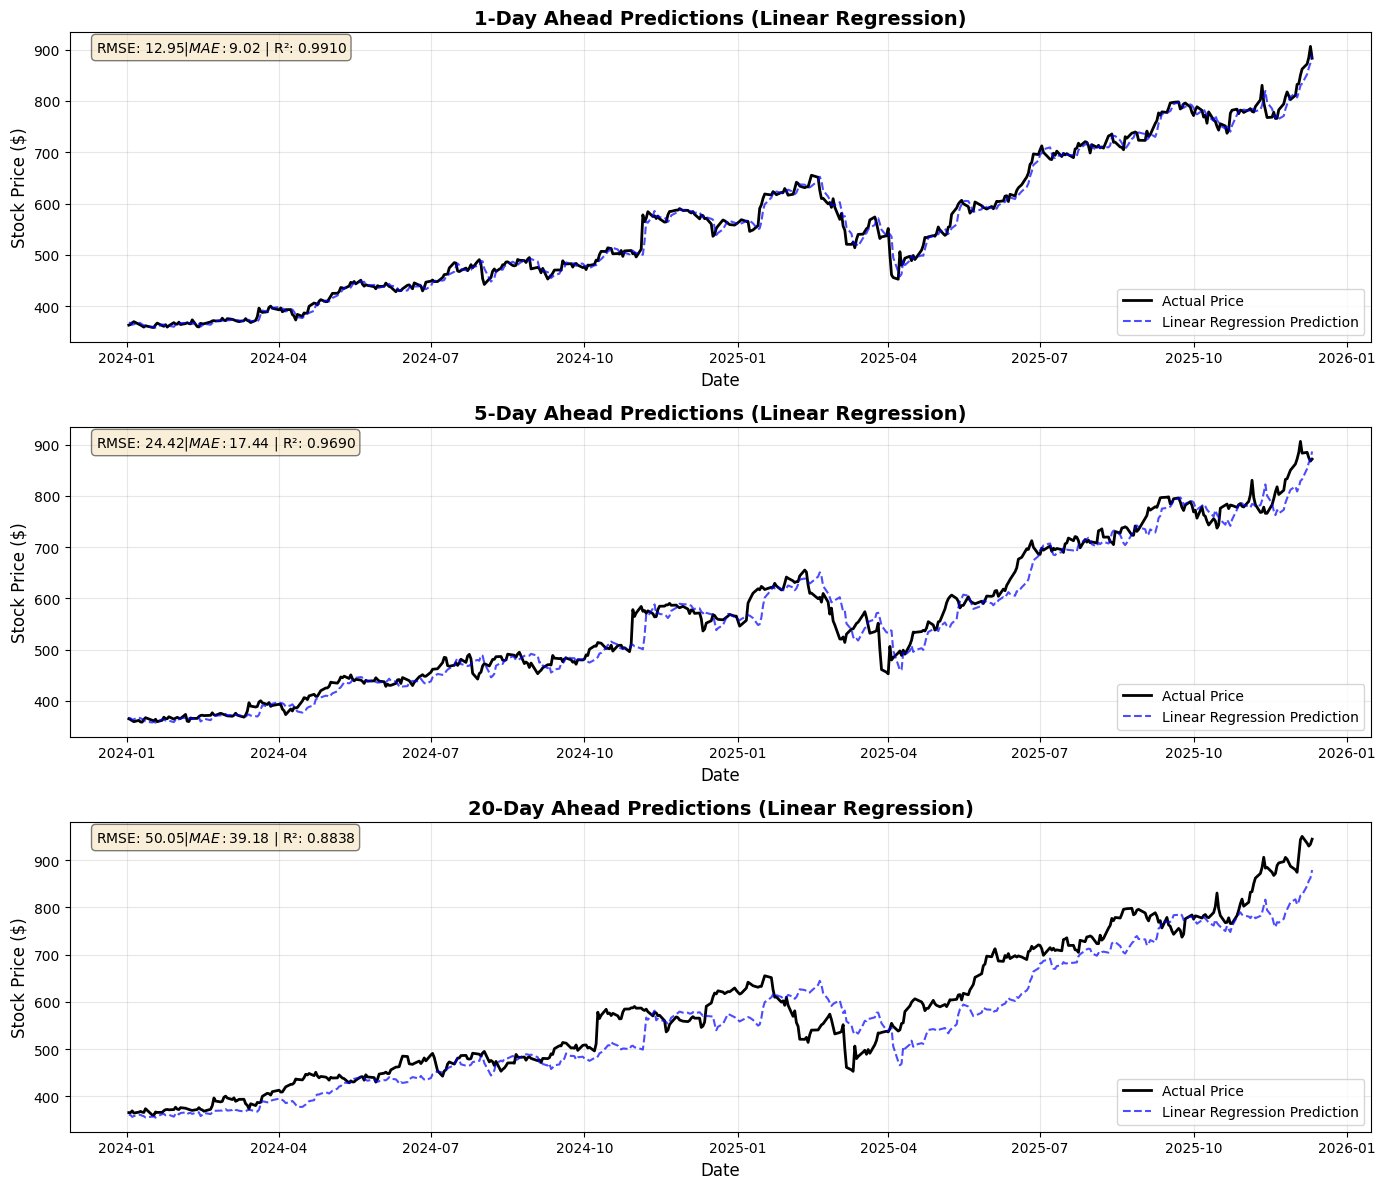

In [31]:
# Creating comparison plots for Linear Regression
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, horizon in enumerate([1, 5, 20]):
    ax = axes[idx]
    
    actual = predictions[f'{horizon}d']['actual']
    pred_lr = predictions[f'{horizon}d']['Linear Regression']
    
    dates = test_df['Date'].values[:len(actual)]    
    
    ax.plot(dates, actual, label='Actual Price', color='black', linewidth=2)
    ax.plot(dates, pred_lr, label='Linear Regression Prediction', 
            color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax.set_title(f'{horizon}-Day Ahead Predictions (Linear Regression)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Stock Price ($)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    metrics = results[f'{horizon}d']['Linear Regression']
    text = f"RMSE: ${metrics['RMSE']:.2f} | MAE: ${metrics['MAE']:.2f} | R²: {metrics['R²']:.4f}"
    ax.text(0.02, 0.98, text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

In [33]:
saved_models = {
    '1d': {
        'Linear Regression': models['1d']['Linear Regression'],
        'Random Forest': models['1d']['Random Forest'],
        'XGBoost': models['1d']['XGBoost']
    },
    '5d': {
        'Linear Regression': models['5d']['Linear Regression'],
        'Random Forest': models['5d']['Random Forest'],
        'XGBoost': models['5d']['XGBoost']
    },
    '20d': {
        'Linear Regression': models['20d']['Linear Regression'],
        'Random Forest': models['20d']['Random Forest'],
        'XGBoost': models['20d']['XGBoost']
    }
}

saved_scalers = {
    '1d': scalers['1d'],
    '5d': scalers['5d'],
    '20d': scalers['20d']
}

saved_predictions = predictions
saved_results = results

joblib.dump(saved_models, 'gs_models.joblib')
joblib.dump(saved_scalers, 'gs_scalers.joblib')
joblib.dump(feature_cols, 'feature_columns.joblib')
joblib.dump(saved_predictions, 'gs_predictions.joblib')
joblib.dump(saved_results, 'gs_results.joblib')

df_features.to_csv('gs_processed_data.csv', index=False)
test_df.to_csv('gs_test_data.csv', index=False)